# Sanity Checks
Load the generated manifest and inspect average rolling correlation over time.

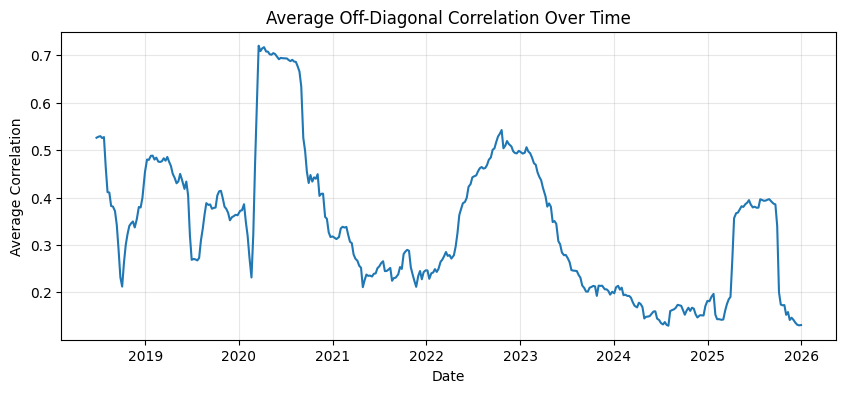

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

manifest = pd.read_csv('../outputs/manifests/matrix_index.csv', parse_dates=['date'])
avg_corr = []
for _, row in manifest.iterrows():
    corr = np.load('../' + row['corr_path'])
    n = corr.shape[0]
    if n < 2:
        avg_corr.append(np.nan)
        continue
    mask = ~np.eye(n, dtype=bool)
    avg_corr.append(float(np.mean(corr[mask])))

plt.figure(figsize=(10, 4))
plt.plot(manifest['date'], avg_corr)
plt.title('Average Off-Diagonal Correlation Over Time')
plt.xlabel('Date')
plt.ylabel('Average Correlation')
plt.grid(alpha=0.3)

plt.show()

## Correlation Heatmap

Render a single correlation matrix snapshot. Change `snapshot_idx` to inspect different dates.

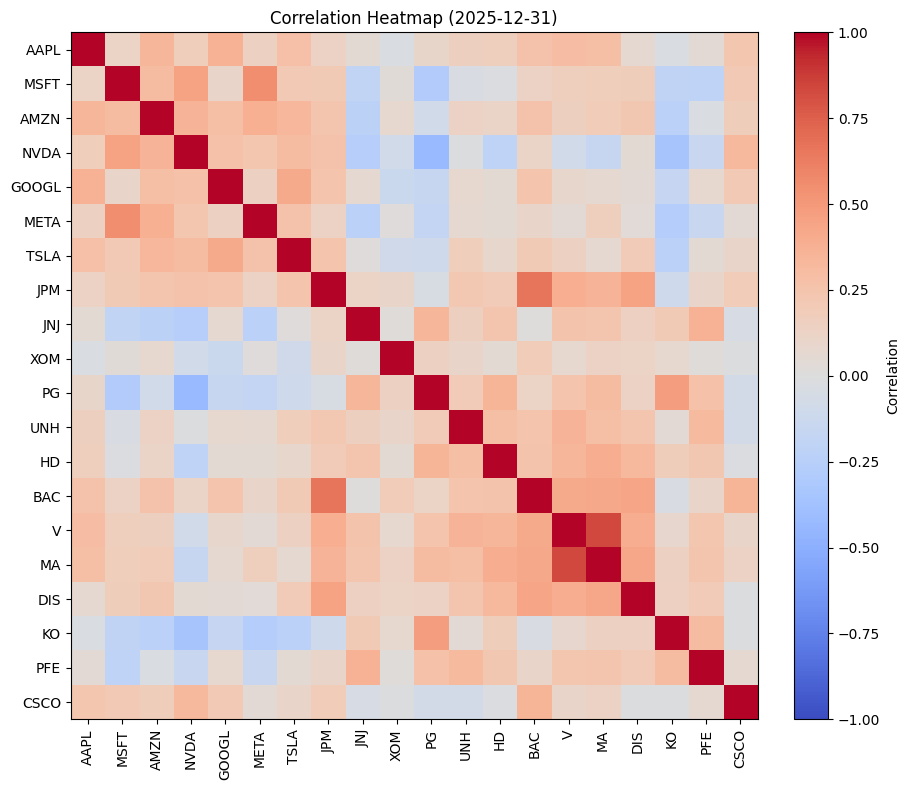

In [8]:
import json

snapshot_idx = -1 # last available snapshot
snapshot = manifest.iloc[snapshot_idx]
corr = np.load('../' + snapshot['corr_path'])
tickers = json.loads(snapshot['tickers_json'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_title(f"Correlation Heatmap ({snapshot['date'].date()})")

if len(tickers) <= 25:
    ax.set_xticks(np.arange(len(tickers)))
    ax.set_yticks(np.arange(len(tickers)))
    ax.set_xticklabels(tickers, rotation=90)
    ax.set_yticklabels(tickers)
else:
    ax.set_xticks([])
    ax.set_yticks([])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()
